In [ ]:
# Importy bibliotek
import torch
import torch_directml
from torchvision import datasets, transforms, models
import numpy as np
from torchvision.models import VGG
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold
from torch.utils.data import DataLoader, Subset, Dataset, ConcatDataset
from preprocess import get_transforms, get_minority_transforms
from config import DATA_PATH, TEST_PATH

In [ ]:
MINORITY_CLASSES = {"disgusted"}

class SelectiveAugDataset(Dataset):
    """
    Obsługuje jeden lub wiele folderów (ImageFolder) i stosuje mocniejszy
    transform dla klas z MINORITY_CLASSES, a standardowy dla pozostałych.
    """

    def __init__(self, roots, minority_transform, base_transform):
        if isinstance(roots, str):
            roots = [roots]

        bases = [datasets.ImageFolder(root=r, transform=None) for r in roots]
        self._loader      = bases[0].loader
        self.classes      = bases[0].classes
        self.class_to_idx = bases[0].class_to_idx

        self.samples = []
        self.targets = []
        for base in bases:
            self.samples.extend(base.samples)
            self.targets.extend(base.targets)

        minority_idx = {
            idx for name, idx in self.class_to_idx.items()
            if name in MINORITY_CLASSES
        }
        self._minority_idx = minority_idx
        self._minority_tf  = minority_transform
        self._base_tf      = base_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]
        img = self._loader(path)
        if label in self._minority_idx:
            img = self._minority_tf(img)
        else:
            img = self._base_tf(img)
        return img, label

# **Przygotowanie danych i transformacje**

In [ ]:
# Domyślny transform — zostanie nadpisany przez preprocess.get_transforms() w main()
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

_ds_train = datasets.ImageFolder(root=DATA_PATH, transform=transform)
_ds_test  = datasets.ImageFolder(root=TEST_PATH,  transform=transform)
dataset   = _ds_train  # używane później do class_names

print(f'Pomyslnie wczytano obrazow: {len(_ds_train) + len(_ds_test)} (train: {len(_ds_train)}, test: {len(_ds_test)})')
print(f'Zidentyfikowane klasy: {dataset.classes}')
print(f'Slownik klas (etykiety numeryczne): {dataset.class_to_idx}')

In [3]:
# Device configuration
if torch_directml.is_available():
    device = torch_directml.device(0)
    print(f"Using DirectML Device: {torch_directml.device_name(0)}")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

Using DirectML Device: AMD Radeon RX 6700 XT 


# **Inicjalizacja modeli**

In [ ]:
def compute_mean_std(data_paths):
    if isinstance(data_paths, str):
        data_paths = [data_paths]
    base_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ])
    ds = ConcatDataset([
        datasets.ImageFolder(root=p, transform=base_transform) for p in data_paths
    ])
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)

    mean = torch.zeros(3)
    std = torch.zeros(3)
    n_samples = 0

    for images, _ in loader:
        batch_size = images.size(0)
        images = images.view(batch_size, 3, -1)
        mean += images.mean(dim=2).sum(dim=0)
        std += images.std(dim=2).sum(dim=0)
        n_samples += batch_size

    mean /= n_samples
    std /= n_samples

    print(f"Mean: {mean.tolist()}")
    print(f"Std:  {std.tolist()}")
    return mean.tolist(), std.tolist()

dataset_mean, dataset_std = compute_mean_std([DATA_PATH, TEST_PATH])

In [ ]:
def get_model(model_name):
    numer_of_classes = 7  # 7 klas: 'angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised'

    if model_name == 'vgg':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        for param in model.parameters():
            param.requires_grad = False
        for param in model.features[24:].parameters():
            param.requires_grad = True
        model.classifier[6] = torch.nn.Linear(4096, numer_of_classes)

    elif model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True
        model.fc = torch.nn.Linear(512, numer_of_classes)

    elif model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True
        model.fc = torch.nn.Linear(2048, numer_of_classes)

    else:
        raise ValueError("Nieznany model")

    return model.to(device)

In [ ]:
def train_and_evaluate(model_name, dataset, test_dataset, class_weights, epochs=1):
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    pretrained_params = [p for n, p in model_name.named_parameters()
                         if p.requires_grad and not any(fc in n for fc in ['fc', 'classifier.6'])]
    new_params = [p for n, p in model_name.named_parameters()
                  if p.requires_grad and any(fc in n for fc in ['fc', 'classifier.6'])]

    optimizer = optim.Adam([
        {'params': pretrained_params, 'lr': 1e-4},
        {'params': new_params,        'lr': 1e-3},
    ])

    for epoch in range(epochs):
        model_name.train()
        for inputs, labels in dataset:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model_name(inputs)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

    model_name.eval()
    all_predictions = []
    correct_predictions = []
    with torch.no_grad():
        for inputs, labels in test_dataset:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_name(inputs)
            _, batch_preds = torch.max(outputs.data, 1)
            all_predictions.extend(batch_preds.cpu().numpy())
            correct_predictions.extend(labels.cpu().numpy())

    acc = accuracy_score(correct_predictions, all_predictions)
    bal_acc = balanced_accuracy_score(correct_predictions, all_predictions)
    prec = precision_score(correct_predictions, all_predictions, average='weighted', zero_division=0)
    rec = recall_score(correct_predictions, all_predictions, average='weighted', zero_division=0)
    cm = confusion_matrix(correct_predictions, all_predictions)

    return acc, bal_acc, prec, rec, cm

In [8]:
def run_experiment(model_name, train_dataset, test_dataset, epochs=1):
  num_classes = len(train_dataset.classes)
  accuracies = []
  balanced_accuracies = []
  precisions = []
  recalls = []
  confusion_matrices = []

  rskf = RepeatedStratifiedKFold(n_splits=2, n_repeats=5, random_state=42)

  for fold, (train_index, test_index) in enumerate(rskf.split(np.arange(len(train_dataset)), train_dataset.targets)):

    train_subset = Subset(train_dataset, train_index)
    test_subset  = Subset(test_dataset,  test_index)

    # Obliczenie wag klas z podzbioru treningowego do CrossEntropy
    train_targets = torch.tensor([train_dataset.targets[i] for i in train_index])
    class_counts = torch.bincount(train_targets, minlength=num_classes).float()
    class_weights = len(train_index) / (num_classes * class_counts)
    class_weights = class_weights.to(device)

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
    test_loader  = DataLoader(test_subset,  batch_size=32, shuffle=False)

    model = get_model(model_name)
    acc, bal_acc, prec, rec, cm = train_and_evaluate(model, train_loader, test_loader, class_weights, epochs)

    accuracies.append(acc)
    balanced_accuracies.append(bal_acc)
    precisions.append(prec)
    recalls.append(rec)
    confusion_matrices.append(cm)

    print(f"Accuracy: {acc:.4f}, Balanced Accuracy: {bal_acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}")

  return accuracies, balanced_accuracies, precisions, recalls, confusion_matrices


In [ ]:
def main(num_models, model_names, epochs_list, mean=None, std=None):
    if len(model_names) != num_models or len(epochs_list) != len(model_names):
        raise ValueError(f'Podano num_models={num_models}, ale lista modeli zawiera {len(model_names)} elementow, a lista epochs_list zawiera {len(epochs_list)} elementow.')

    roots = [DATA_PATH, TEST_PATH]
    results = {}
    for model_name, epochs in zip(model_names, epochs_list):
        print(f'=== Trening modelu: {model_name} ===')
        minority_tf   = get_transforms(model_name, mean=mean, std=std)
        base_tf       = get_transforms(model_name, mean=mean, std=std)
        train_dataset = SelectiveAugDataset(roots, minority_tf, base_tf)
        test_dataset  = SelectiveAugDataset(roots, base_tf,     base_tf)
        accs, bal_accs, precs, recs, cms = run_experiment(model_name, train_dataset, test_dataset, epochs)
        results[model_name] = {
            'accuracies':          accs,
            'balanced_accuracies': bal_accs,
            'precisions':          precs,
            'recalls':             recs,
            'confusion_matrices':  cms,
        }
        print(f'Srednia Accuracy:          {sum(accs)/len(accs):.4f}')
        print(f'Srednia Balanced Accuracy: {sum(bal_accs)/len(bal_accs):.4f}')
        print(f'Srednia Precision:         {sum(precs)/len(precs):.4f}')
        print(f'Srednia Recall:            {sum(recs)/len(recs):.4f}')

    return results

In [10]:
results = main(
    num_models=3,
    model_names=['resnet18', 'vgg', 'resnet50'],
    epochs_list=[10, 10, 10],
    mean=dataset_mean, # Custom parametry jesli wlasny dataset
    std=dataset_std,
)


=== Trening modelu: resnet18 ===


C:\Users\karol\Downloads\pytorch-emotion-detector\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\karol\Downloads\pytorch-emotion-detector\.venv\lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Accuracy: 0.2550, Balanced Accuracy: 0.2414, Precision: 0.2915, Recall: 0.2550


C:\Users\karol\Downloads\pytorch-emotion-detector\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.2946, Balanced Accuracy: 0.2649, Precision: 0.3268, Recall: 0.2946


...

Accuracy: 0.2442, Balanced Accuracy: 0.2598, Precision: 0.3712, Recall: 0.2442


C:\Users\karol\Downloads\pytorch-emotion-detector\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.3163, Balanced Accuracy: 0.3280, Precision: 0.4340, Recall: 0.3163
Srednia Accuracy:          0.2828
Srednia Balanced Accuracy: 0.3019
Srednia Precision:         0.3906
Srednia Recall:            0.2828

=== Trening modelu: resnet50 ===


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\karol/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100.0%


Accuracy: 0.2614, Balanced Accuracy: 0.2449, Precision: 0.3298, Recall: 0.2614
Accuracy: 0.3375, Balanced Accuracy: 0.2713, Precision: 0.2816, Recall: 0.3375
Accuracy: 0.3247, Balanced Accuracy: 0.2820, Precision: 0.3140, Recall: 0.3247
Accuracy: 0.3407, Balanced Accuracy: 0.2860, Precision: 0.3090, Recall: 0.3407
Accuracy: 0.3034, Balanced Accuracy: 0.2680, Precision: 0.3058, Recall: 0.3034
Accuracy: 0.2794, Balanced Accuracy: 0.2464, Precision: 0.3503, Recall: 0.2794
Accuracy: 0.2622, Balanced Accuracy: 0.2799, Precision: 0.3673, Recall: 0.2622
Accuracy: 0.2726, Balanced Accuracy: 0.2623, Precision: 0.3060, Recall: 0.2726
Accuracy: 0.3070, Balanced Accuracy: 0.2724, Precision: 0.2822, Recall: 0.3070
Accuracy: 0.3379, Balanced Accuracy: 0.2945, Precision: 0.3187, Recall: 0.3379
Srednia Accuracy:          0.3027
Srednia Balanced Accuracy: 0.2708
Srednia Precision:         0.3165
Srednia Recall:            0.3027


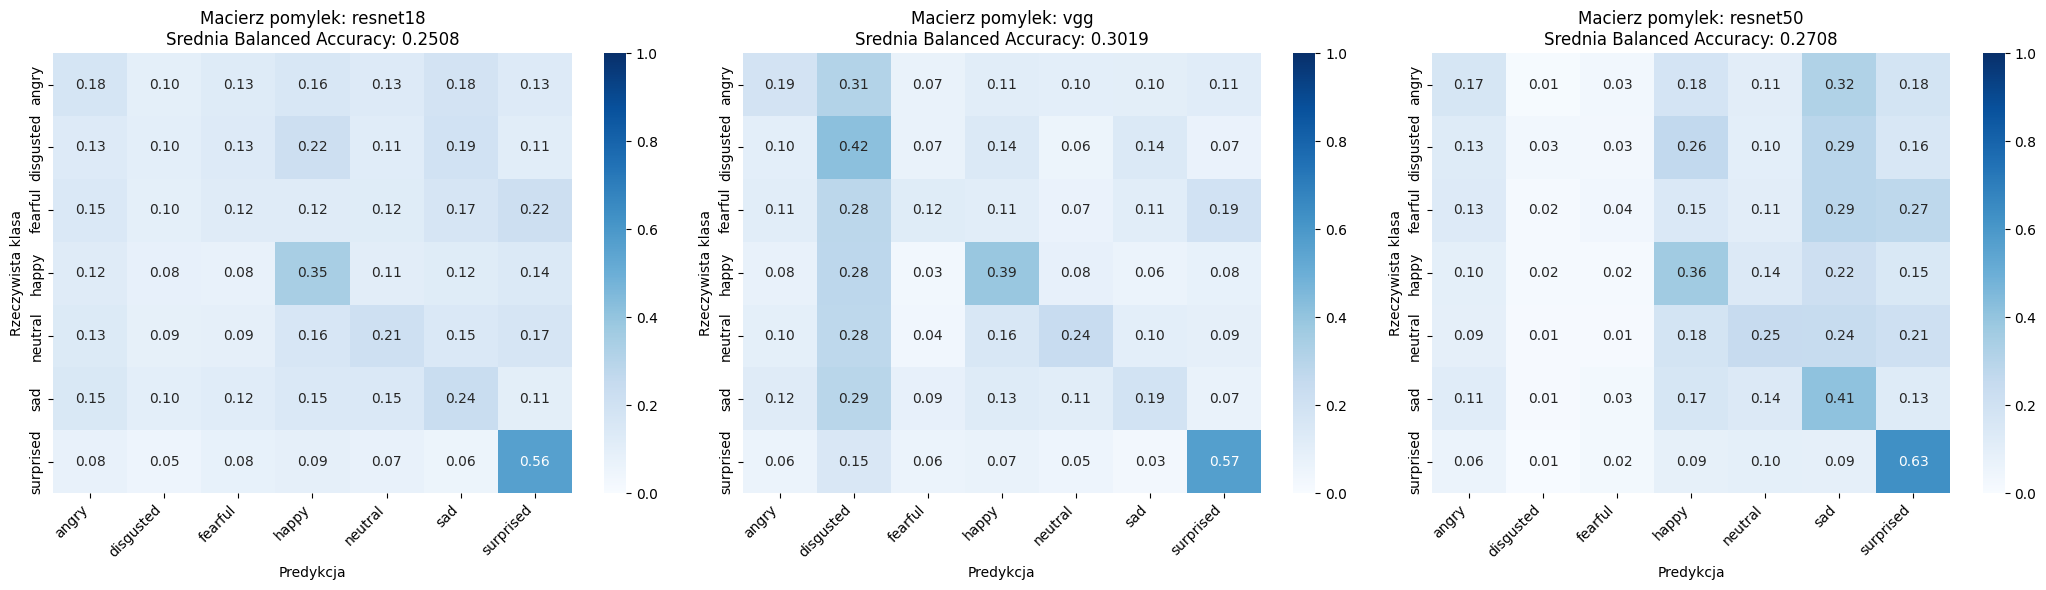

In [11]:
def plot_confusion_matrices(results, class_names):
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, metrics) in zip(axes, results.items()):
        mean_cm = np.mean(metrics['confusion_matrices'], axis=0)
        mean_cm_normalized = mean_cm / mean_cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            mean_cm_normalized,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            vmin=0, vmax=1,
            ax=ax
        )
        bal_acc_mean = np.mean(metrics['balanced_accuracies'])
        ax.set_title(f'Macierz pomylek: {model_name}\nSrednia Balanced Accuracy: {bal_acc_mean:.4f}')
        ax.set_xlabel('Predykcja')
        ax.set_ylabel('Rzeczywista klasa')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

class_names = dataset.classes
plot_confusion_matrices(results, class_names)

In [ ]:
def plot_per_class_metrics(results, class_names):
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, metrics) in zip(axes, results.items()):
        mean_cm   = np.mean(metrics['confusion_matrices'], axis=0)
        recall    = np.diag(mean_cm) / (mean_cm.sum(axis=1) + 1e-8)
        precision = np.diag(mean_cm) / (mean_cm.sum(axis=0) + 1e-8)
        f1        = 2 * precision * recall / (precision + recall + 1e-8)

        x = np.arange(len(class_names))
        w = 0.25
        ax.bar(x - w, precision, w, label='Precision')
        ax.bar(x,     recall,    w, label='Recall')
        ax.bar(x + w, f1,        w, label='F1')
        ax.set_xticks(x)
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_ylim(0, 1)
        ax.set_title(f'Per-class metrics: {model_name}')
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_per_class_metrics(results, class_names)

In [ ]:
def plot_model_comparison(results):
    model_names = list(results.keys())
    accs      = [np.mean(results[m]['accuracies'])          for m in model_names]
    bal_accs  = [np.mean(results[m]['balanced_accuracies']) for m in model_names]
    precs     = [np.mean(results[m]['precisions'])          for m in model_names]
    recs      = [np.mean(results[m]['recalls'])             for m in model_names]

    x = np.arange(len(model_names))
    w = 0.2
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - 1.5*w, accs,     w, label='Accuracy')
    ax.bar(x - 0.5*w, bal_accs, w, label='Balanced Accuracy')
    ax.bar(x + 0.5*w, precs,    w, label='Precision')
    ax.bar(x + 1.5*w, recs,     w, label='Recall')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylim(0, 1)
    ax.set_title('Porównanie modeli — średnie metryki')
    ax.legend()
    plt.tight_layout()
    plt.show()


def print_error_analysis(results, class_names):
    for model_name, metrics in results.items():
        mean_cm      = np.mean(metrics['confusion_matrices'], axis=0)
        mean_cm_norm = mean_cm / (mean_cm.sum(axis=1, keepdims=True) + 1e-8)

        errors = [
            (mean_cm_norm[i, j], class_names[i], class_names[j])
            for i in range(len(class_names))
            for j in range(len(class_names))
            if i != j
        ]
        errors.sort(reverse=True)

        print(f"\n=== {model_name} — najczęstsze błędy klasyfikacji ===")
        print(f"{'Prawdziwa':<12} → {'Predykcja':<12}  {'Częstość':>8}")
        for rate, true_cls, pred_cls in errors[:5]:
            print(f"{true_cls:<12} → {pred_cls:<12}  {rate:>8.2%}")


plot_model_comparison(results)
print_error_analysis(results, class_names)

In [ ]:
import pickle
with open("results.pkl", "wb") as f:
    pickle.dump(results,f)